In [1]:
from sklearn.datasets import make_classification

# 데이터 생성
X, y = make_classification(n_features=1, n_samples=300, 
                           n_redundant=0, n_informative=1,
                           n_clusters_per_class=1, class_sep=0.5,
                           random_state=0)
# n_feature=1, 독립 변수(특성)의 수를 1로 한다. 
# n_samples=300, 샘플(데이터 포인트)의 총 개수를 300으로 설정합니다. 
# n_redundant=0, 중복되는(불필요한) 특성의 수를 0으로 설정 
# n_informative=1, 유익한(목표 변수와 관계 있는) 특성의 수를 1로 설정 
# n_clusters_per_class=1, 각 클래스별 클러스터의 수를 1로 설정, 각 클래스가 하나의 밀집된 클러스터로 구성되어 있음을 의미 
# class_sep=0.5, 클래스 간 분리 정도를 설정, 값이 클 수록 클래스 간에 분리가 뚜렷
# random_state=0, 결과의 재현 가능성을 위해 랜덤 상태(seed)를 0으로 고정 
# x: 1차원 데이터, 연속형 변수 
# y: 종속 변수로 0 또는 1값을 가지고 있는 이진 변수 

print(X.shape, y.shape)

(300, 1) (300,)


`n_features`는 **입력 벡터의 차원(독립변수 개수)**을 의미합니다.

수학적으로 각 샘플을  
$$
\mathbf{x}^{(i)} \in \mathbb{R}^{d}
$$  
로 쓰면, 여기서 $d = n\_features$ 입니다.

- `n_features = 1`이면: 각 샘플이 실수 1개 \((x)\)
- `n_features = 2`이면: 각 샘플이 \((x_1, x_2)\)
- 일반적으로 데이터 행렬은  
$$
X \in \mathbb{R}^{n\_samples \times n\_features}
$$  
형태입니다.

로지스틱 회귀에서는  
$$
z = \mathbf{w}^\top \mathbf{x} + b
$$  
에서 가중치 벡터 \(\mathbf{w}\)의 길이도 `n_features`와 같습니다.  
즉, **특성이 늘수록 모델이 학습해야 할 파라미터 수도 늘어납니다**.

In [4]:
print(X[:5])

[[-0.75193919]
 [ 0.63073916]
 [-0.63168397]
 [-0.21203669]
 [ 0.72433503]]


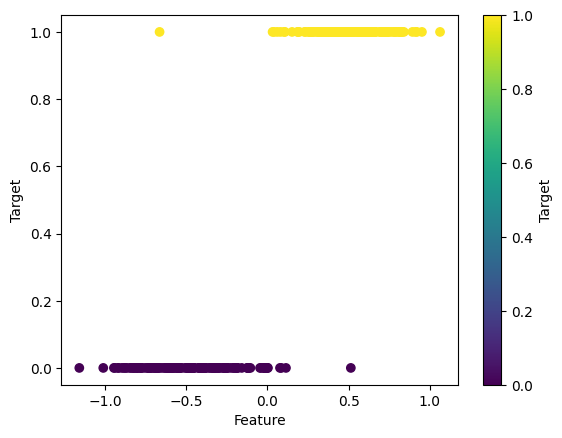

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X, y, c=y)
plt.xlabel('Feature')
plt.ylabel('Target')
plt.colorbar(label='Target')
plt.show()

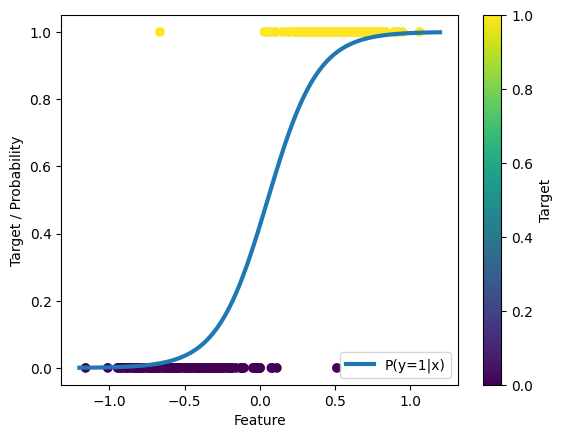

In [6]:
from sklearn.linear_model import LogisticRegression

# LogisticRegression: 이진 분류(0/1)를 위한 대표적인 선형 분류 모델입니다.
# 내부적으로는 입력 x에 대해 z = w*x + b를 계산한 뒤,
# 시그모이드 함수(sigmoid)를 적용해 클래스 1일 확률 P(y=1|x)을 추정합니다.
model = LogisticRegression()

# fit(X, y): 입력 특성 X와 정답 레이블 y를 사용해 모델 파라미터(w, b)를 학습합니다.
# 현재 X의 shape은 (샘플 수, 1)이며, y는 0/1 레이블입니다.
model.fit(X, y)

import numpy as np

# 시각화를 위해 x축 구간을 촘촘하게 만듭니다.
# -1.2 ~ 1.2 사이를 100개 점으로 나누고
# reshape(-1, 1)로 (100, 1) 형태(모델 입력 형식)로 변환합니다.
x_data = np.linspace(-1.2, 1.2, 100).reshape(-1, 1)

# predict_proba(x_data): 각 점에 대해 [P(class 0), P(class 1)]를 반환합니다.
# [:, 1]은 클래스 1일 확률만 추출합니다.
pred = model.predict_proba(x_data)[:, 1]

# x축(x_data) 대비 클래스 1 확률(pred)을 곡선으로 그립니다.
# 이 곡선이 로지스틱 회귀의 시그모이드 확률 곡선입니다.
plt.plot(x_data, pred, lw=3, label='P(y=1|x)')

# 원본 데이터 산점도입니다.
# y가 0/1 값이므로 점들이 아래(0)와 위(1)에 모여 보입니다.
# c=y로 클래스에 따라 색을 다르게 표시합니다.
plt.scatter(X, y, c=y)

# 그래프 라벨/범례/컬러바를 추가해 해석을 쉽게 합니다.
plt.xlabel('Feature')
plt.ylabel('Target / Probability')
plt.legend()
plt.colorbar(label='Target')
plt.show()